In [6]:
%load_ext autoreload
%autoreload 2

import cupy as cp
from utils.data_loader import ImagenetteDataLoader
from model import Network

import warnings
warnings.filterwarnings("ignore")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Loading the Data

In [2]:
train_loader = ImagenetteDataLoader(
    root_path="input/imagenette2",
    split="train",
    target_size=(224, 224)
)

x_train, y_train = train_loader.load_images(normalize=True)
x_train.shape, y_train.shape

((9469, 3, 224, 224), (9469, 10))

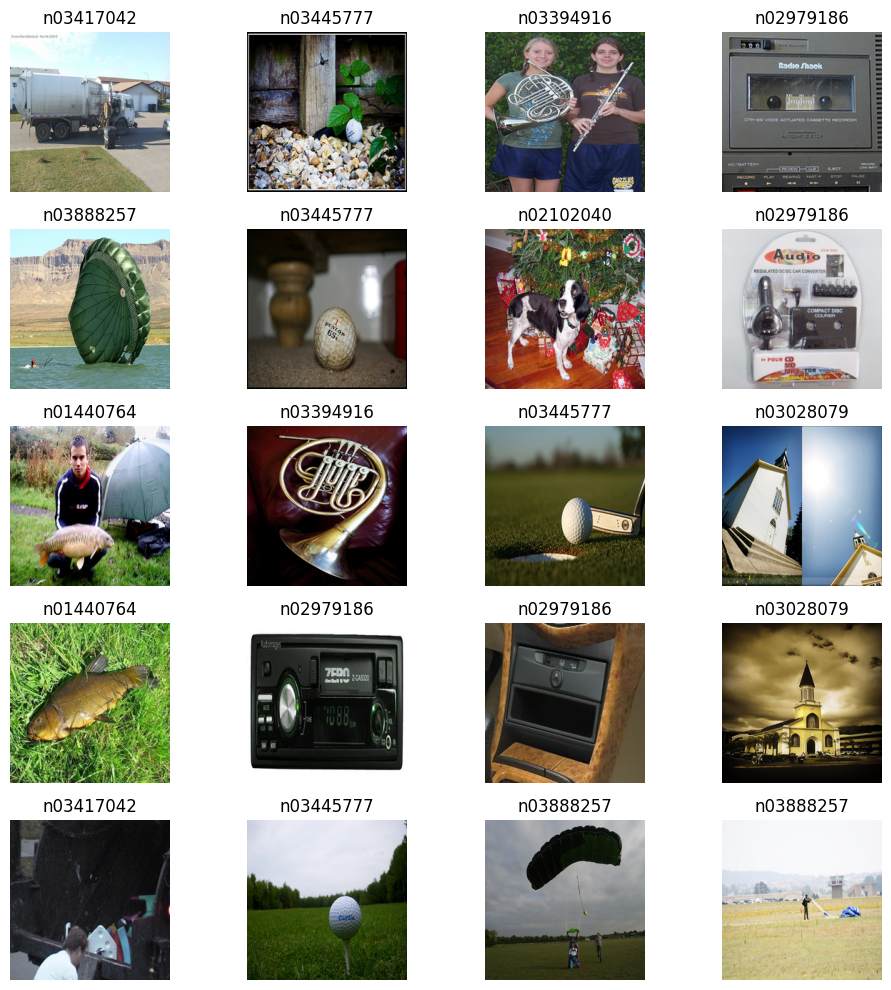

In [3]:
random_indices = cp.random.randint(0, len(x_train), size=20)
train_loader.plot_batch(random_indices.get().tolist(), figsize=(10, 10))

In [4]:
layer_definitions = [
    {"type": "Conv", "num_filters": 5, "kernel_height": 3, "kernel_width": 3, "padding": 0, "stride": 1},
    {"type": "ReLU", "input_size": 300, "num_neurons": 300},
    {"type": "ReLU", "input_size": 300, "num_neurons": 200},
    {"type": "ReLU", "input_size": 200, "num_neurons": 100},
    {"type": "ReLU", "input_size": 100, "num_neurons": 50},
    {"type": "Sigmoid", "input_size": 50, "num_neurons": 10}
]

network = Network(layer_definitions=layer_definitions)

In [5]:
network.describe()

Network Architecture

Layer 1: ConvLayer
  Filters Shape: (5, 3, 3, 3)
  Parameters: 135

Layer 2: ReluLayer
  Weights Shape: (300, 300) | Biases Shape: (300,)
  Parameters: 90,300

Layer 3: ReluLayer
  Weights Shape: (300, 200) | Biases Shape: (200,)
  Parameters: 60,200

Layer 4: ReluLayer
  Weights Shape: (200, 100) | Biases Shape: (100,)
  Parameters: 20,100

Layer 5: ReluLayer
  Weights Shape: (100, 50) | Biases Shape: (50,)
  Parameters: 5,050

Layer 6: SigmoidLayer
  Weights Shape: (50, 10) | Biases Shape: (10,)
  Parameters: 510

Total Parameters: 176,295
